# ¿De dónde proviene la desigualdad de riqueza?

El riesgo idiosincrático de ingresos combinado con una restricción de
endeudamiento lleva a los hogares a ahorrar por motivos precautorios, lo que
genera una distribución no degenerada de riqueza incluso cuando todos son
*ex-ante* idénticos. Resolvemos el equilibrio general de **Aiyagari (1994)**,
lo contrastamos con la economía de bonos de **Huggett (1993)**, y mostramos
que incorporar heterogeneidad *ex-ante* en la paciencia (β) engrosa la cola
superior — la razón canónica por la que los modelos cuantitativos necesitan
heterogeneidad permanente para replicar los datos. Todo con `puremacro.vfi`.

## El modelo en tres ecuaciones

**Hogares.** Un continuo de hogares enfrentan riesgo idiosincrático de productividad laboral $z$
(un AR(1), discretizado por Tauchen) y no pueden endeudarse. Resuelven
$$ V(a,z) = \max_{a'\ge 0}\; u(c) + \beta\,\mathbb{E}\!\left[V(a',z')\mid z\right]
\quad\text{s.a.}\quad c = w\,e^{z} + (1+r)\,a - a', $$
con $u(c)=\log c$ aquí ($\gamma=1$). La restricción $a'\ge 0$ es el motor del modelo.

**Empresas.** Una firma representativa con tecnología Cobb-Douglas fija los precios de
los factores a partir de los agregados:
$$ r = \alpha\,(K/L)^{\alpha-1} - \delta, \qquad w = (1-\alpha)\,(K/L)^{\alpha}. $$

**Equilibrio.** Sea $\mu$ la distribución estacionaria inducida por la política de ahorro.
La tasa de interés vacía el mercado de capital, $K = \int a\, d\mu(a,z)$. En **Huggett** el
activo es un bono de oferta neta cero, de modo que el vaciamiento es $\int a\,d\mu = 0$ y
la tasa de equilibrio se sitúa estrictamente por debajo de $1/\beta-1$.

**Intuición.** Sin posibilidad de endeudarse y con riesgo de ingresos no asegurable, los
hogares se auto-aseguran acumulando una reserva precautoria de activos. Esa reserva explica
por qué emerge una distribución de riqueza no degenerada aunque todos sean *ex-ante*
idénticos — y por qué la tasa de equilibrio se sitúa por debajo del valor de mercados
completos $1/\beta-1$: el exceso de deseo de ahorrar comprime la rentabilidad. Las
diferencias permanentes en paciencia $\beta$ estiran aún más la distribución — los hogares
pacientes escalan la grilla de activos, los impacientes se acumulan cerca de la restricción.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.vfi import (
    aiyagari_steady_state, huggett_steady_state, lorenz_and_gini,
    VFIProblem, solve_permanent_types,
)

## 1. Aiyagari: mercados incompletos en equilibrio general
Los hogares enfrentan riesgo de productividad laboral AR(1) y no pueden
endeudarse (`a ≥ 0`); la tasa de interés se ajusta de modo que el ahorro
de los hogares iguale la demanda de capital de las firmas.

In [2]:
ai = aiyagari_steady_state(n_z=5, n_a=120, a_max=60.0, gamma=1.0)
eq = ai["equilibrium"]
a_grid = np.asarray(eq.problem.a_grid, dtype=float)
z_grid = np.asarray(eq.problem.z_grid, dtype=float)
P_z = np.asarray(eq.problem.P_z, dtype=float)
mu_ai = eq.distribution                                  # (n_a, n_z)
gini_ai = ai["wealth_gini"]
print(f"Aiyagari:  r* = {ai['r']:.4f},  K = {ai['K']:.2f},  wealth Gini = {gini_ai:.3f}")
assert 0.40 < gini_ai < 0.80, gini_ai   # docstring: n_z=5 gives a stable Gini ~0.6

Aiyagari:  r* = 0.0306,  K = 7.48,  wealth Gini = 0.632


**Lee el resultado.** El punto de referencia de mercados completos es $1/\beta-1 = 1/0.96-1 \approx 0.042$.
El $r^*$ de equilibrio impreso arriba se sitúa *por debajo* de ese valor: esa brecha es la
cuña precautoria — la demanda de activos para auto-asegurarse comprime la tasa de retorno.
El índice de Gini de riqueza cercano a $0.6$ se genera únicamente por el riesgo idiosincrático
y la restricción de endeudamiento, sin ninguna heterogeneidad ex-ante todavía.

## 2. La heterogeneidad permanente en β engrosa la cola superior
Mantenemos los precios de Aiyagari fijos y dividimos la población en un tipo
*paciente* y uno *impaciente*. Los pacientes acumulan más activos; los
impacientes se concentran cerca de la restricción de endeudamiento. La mezcla
poblacional es más dispersa que la economía homogénea.

In [3]:
alpha, delta = 0.36, 0.08
def wage_of_r(r):
    KL = (alpha / (r + delta)) ** (1.0 / (1.0 - alpha))
    return (1.0 - alpha) * KL ** alpha

r_star, w_star = ai["r"], wage_of_r(ai["r"])
betas, weights = [0.96, 0.93], [0.5, 0.5]

def build_type(t):
    b = betas[t]
    def rf(ap, a, z, xp=np):
        c = w_star * xp.exp(z) + (1.0 + r_star) * a - ap
        return xp.where(c > 0.0, xp.log(xp.maximum(c, 1e-12)), -np.inf)
    return VFIProblem(a_grid=a_grid, z_grid=z_grid, P_z=P_z, return_fn=rf,
                      beta=b, options=dict(tol=1e-9, n_howard=40))

pt = solve_permanent_types(build_type, weights)
mu_mix = pt.mixture_distribution()
wealth_mix = np.broadcast_to(a_grid[:, None], mu_mix.shape)
_, _, gini_mix = lorenz_and_gini(mu_mix, wealth_mix)
print(f"β-heterogeneous mixture wealth Gini = {gini_mix:.3f}  (vs {gini_ai:.3f})")
assert gini_mix > gini_ai, (gini_mix, gini_ai)   # if marginal, widen the β spread (e.g. 0.92)

β-heterogeneous mixture wealth Gini = 0.794  (vs 0.632)


## 3. Huggett: una economía de bonos con oferta neta cero
Economía de intercambio puro donde el único activo es un bono de suma neta
cero. La tasa de equilibrio se sitúa por debajo de `1/β − 1`; algunos
agentes se endeudan.

In [4]:
hu = huggett_steady_state(n_z=7, n_a=150)
a_grid_hu = np.asarray(hu["equilibrium"].problem.a_grid, dtype=float)
mu_hu = hu["equilibrium"].distribution
print(f"Huggett:   r = {hu['r']:.4f},  mean assets = {hu['mean_assets']:.2e}, "
      f"borrowing share = {hu['frac_borrowing']:.2f}")
assert abs(hu["equilibrium"].residual) < 1e-2
assert 0.0 < hu["frac_borrowing"] < 1.0

Huggett:   r = 0.0046,  mean assets = 7.18e-04, borrowing share = 0.68


### Figura principal — curvas de Lorenz
La mezcla con heterogeneidad en β se aleja más de la línea de 45° de
igualdad perfecta.

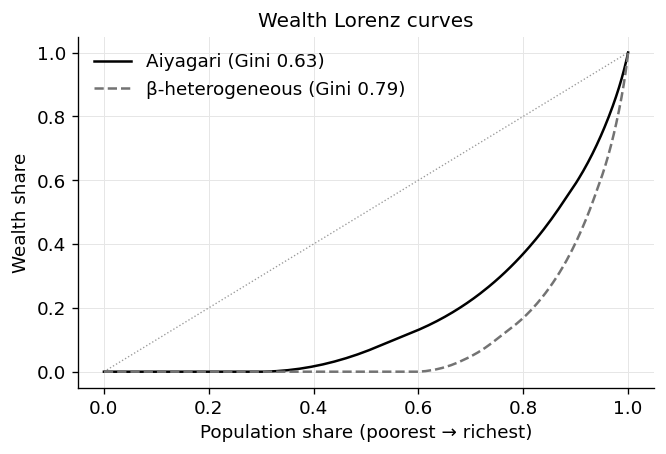

In [5]:
cols = _nbstyle.palette(2)
pop_ai, val_ai, _ = lorenz_and_gini(mu_ai, np.broadcast_to(a_grid[:, None], mu_ai.shape))
pop_mx, val_mx, _ = lorenz_and_gini(mu_mix, wealth_mix)
fig, ax = plt.subplots()
ax.plot([0, 1], [0, 1], color="0.6", linewidth=0.8, linestyle=":")
ax.plot(pop_ai, val_ai, color=cols[0], label=f"Aiyagari (Gini {gini_ai:.2f})")
ax.plot(pop_mx, val_mx, color=cols[1], linestyle="--",
        label=f"β-heterogeneous (Gini {gini_mix:.2f})")
ax.set_xlabel("Population share (poorest → richest)")
ax.set_ylabel("Wealth share")
ax.set_title("Wealth Lorenz curves")
ax.legend(loc="upper left")
plt.show()

### Complementaria — densidad de riqueza por estado de ingreso y distribución de activos en Huggett

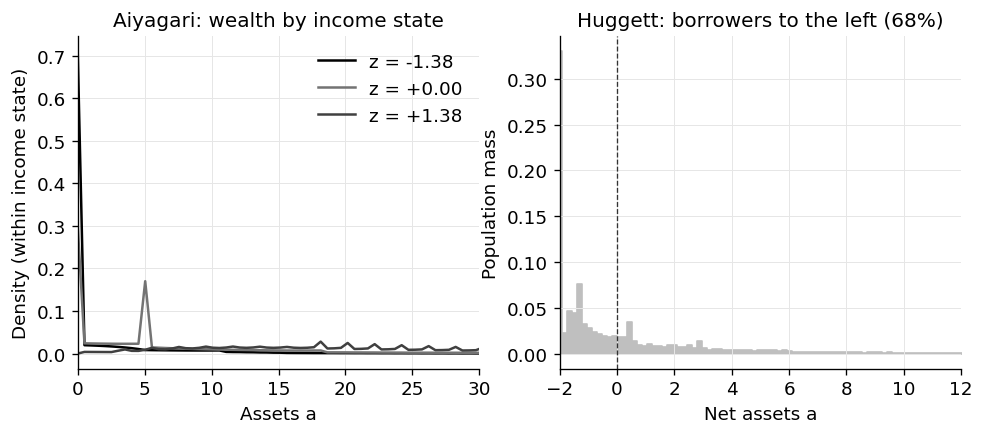

In [6]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(9.5, 3.6))
dens_ai = mu_ai / mu_ai.sum(axis=0, keepdims=True)       # column-normalize per z
for j, c in zip([0, len(z_grid) // 2, len(z_grid) - 1], _nbstyle.palette(3)):
    axL.plot(a_grid, dens_ai[:, j], color=c, label=f"z = {z_grid[j]:+.2f}")
axL.set_xlim(0, 30)
axL.set_xlabel("Assets a"); axL.set_ylabel("Density (within income state)")
axL.set_title("Aiyagari: wealth by income state"); axL.legend()

mu_hu_a = mu_hu.sum(axis=1)                               # marginal over z
axR.fill_between(a_grid_hu, mu_hu_a, color="0.75", step="mid")
axR.axvline(0.0, color="0.2", linewidth=0.8, linestyle="--")
axR.set_xlim(a_grid_hu[0], 12)
axR.set_xlabel("Net assets a"); axR.set_ylabel("Population mass")
axR.set_title(f"Huggett: borrowers to the left ({hu['frac_borrowing']:.0%})")
plt.show()

### Complementaria — la política de consumo-ahorro
Por debajo de un umbral la restricción de endeudamiento es vinculante y
`a' = 0` (el segmento plano sobre la línea de 45°); por encima de él los
hogares ahorran a partir de un ingreso mayor.

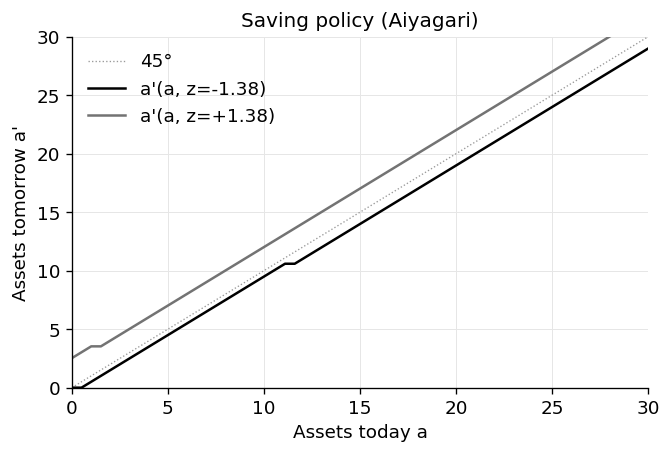

In [7]:
pol_a = a_grid[eq.solution.policy_aprime]                 # (n_a, n_z) realized a'
fig, ax = plt.subplots()
ax.plot(a_grid, a_grid, color="0.6", linewidth=0.8, linestyle=":", label="45°")
for j, c in zip([0, len(z_grid) - 1], _nbstyle.palette(2)):
    ax.plot(a_grid, pol_a[:, j], color=c, label=f"a'(a, z={z_grid[j]:+.2f})")
ax.set_xlim(0, 30); ax.set_ylim(0, 30)
ax.set_xlabel("Assets today a"); ax.set_ylabel("Assets tomorrow a'")
ax.set_title("Saving policy (Aiyagari)"); ax.legend(loc="upper left")
plt.show()

## Tu turno — ¿cuánto importa la heterogeneidad en la paciencia?

La mezcla anterior usó `betas = [0.96, 0.93]`. Amplía o reduce la brecha — *manteniendo los
precios fijos*, por lo que es barato (sin re-solución de EG) — y observa cómo responde el
Gini. Cambia `betas_you`.

Consejo: ampliar el lado *impaciente* es la palanca confiable. Lleva la β *paciente* a 0.97+
y el Gini puede incluso *caer* — a la tasa fija esos hogares ascienden y se acumulan en el
tope de la grilla de activos `a_max`, lo que comprime la cola superior de la distribución.

In [8]:
# ← Change this β spread (patient first, impatient second). Keep both < 1.
betas_you, weights_you = [0.96, 0.92], [0.5, 0.5]

def build_type_you(t):
    b = betas_you[t]
    def rf(ap, a, z, xp=np):
        c = w_star * xp.exp(z) + (1.0 + r_star) * a - ap
        return xp.where(c > 0.0, xp.log(xp.maximum(c, 1e-12)), -np.inf)
    return VFIProblem(a_grid=a_grid, z_grid=z_grid, P_z=P_z, return_fn=rf,
                      beta=b, options=dict(tol=1e-9, n_howard=40))

pt_you = solve_permanent_types(build_type_you, weights_you)
mu_you = pt_you.mixture_distribution()
_, _, gini_you = lorenz_and_gini(mu_you, np.broadcast_to(a_grid[:, None], mu_you.shape))
print(f"β spread {betas_you}: mixture Gini = {gini_you:.3f}  "
      f"(baseline [0.96, 0.93] → {gini_mix:.3f}; homogeneous → {gini_ai:.3f})")
assert gini_you > gini_ai, f"{gini_you:.3f} ≤ {gini_ai:.3f}: a near-unit-root patient β piles mass at a_max and compresses the top — see the Tip above"

β spread [0.96, 0.92]: mixture Gini = 0.801  (baseline [0.96, 0.93] → 0.794; homogeneous → 0.632)


**Ejercicios.** (1) Reduce la brecha a `[0.955, 0.945]` — ¿cae el Gini hacia el valor
homogéneo? (2) Haz los pesos asimétricos (`[0.8, 0.2]`). (3) *Extensión* (lento, re-resuelve
EG): llama a `aiyagari_steady_state(..., sigma=0.30)` para aumentar el riesgo de ingresos y
compara `wealth_gini` con el caso base `sigma=0.2`.

**¿Qué tan completa es la biblioteca?** `puremacro.vfi` es un kit de herramientas completo
para agentes heterogéneos. El mismo ciclo `VFIProblem` → solución → distribución estacionaria
→ vaciamiento de mercado impulsa los demás cuadernos de muestra: **Krusell-Smith** con riesgo
agregado y trayectorias de transición (NB02), **ciclo de vida / OLG** con mortalidad (NB03),
**Hopenhayn** con entrada y salida de firmas (NB04), y carteras de **dos activos** con EGM y
preferencias de Epstein-Zin (NB05). Las grillas endógenas, los tipos permanentes y las
transiciones de EG son todos de primera clase.